### Utility Maximization under Fake stationary Rough Heston Volatility and Fractional Riccati Volterra Integral Equations(FRVIE).

- This notebook is a complementary material of [Gnab2026](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=6422558), authored by [Emmanuel Gnabeyeu](https://emma-gnabeyeu.github.io/). It illustrates the implementation of the fake stationary rough Heston model, the solution of inhomogeneous Riccati--Volterra equations, and the optimal strategy for the Merton portfolio selection problem under this framework.

- For further details, we refer the reader to [Gnab2026](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=6422558). The code is far from being optimized as it could be significantly improved through parallelisation. For any questions regarding the code or the paper, please feel free to reach out at emmanuel.gnabeyeu-mbiada@polytechnique.org.  I would be grateful for any feedback or suggestions to improve this notebook.

In [3]:
# Decorateur
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.special import gamma, gammainc
from scipy.stats import skew
from scipy.linalg import ldl
from scipy.linalg import cholesky
from scipy.integrate import quad
import scipy.integrate as integrate
from scipy.stats import norm
import scipy.special as sp
import scipy.sparse as sp_sparse
import time
from tqdm import tqdm

from scipy.optimize import minimize

from numpy.polynomial.legendre import leggauss


from numpy.random import default_rng, SeedSequence
import seaborn as sns
from scipy.optimize import fsolve, brentq

sns.set_theme()

sq = SeedSequence()
seed = sq.entropy       # on sauve la graine pour reproduire les résultats
print('seed = ', seed)
rng = default_rng(sq)
rng.standard_normal(5)

seed =  220499902358716858896128551124913415205


array([ 0.94725621, -1.65310428, -1.00920451,  1.29518002,  0.98352847])

## Resolvent $R_{\lambda, \alpha}(t)$ and its anti-derivative $f_{\lambda, \alpha}(t)$ for $\alpha \in (\frac12,1)$ for the Fractional integration kernel.


Let $K(t) = K_{\alpha}(t) = \frac{u^{\alpha-1}}{\Gamma(\alpha)} \mathbb{1}_{\mathbb{R}_+}(t),  \quad \alpha>0.$

This  family of  kernels corresponds to the fractional integrations of order $\alpha >0$.

It follows from the  easy identity  $K_{\alpha}*K_{\alpha'}= K_{\alpha+\alpha'}$ that

$$R_{\alpha,\lambda}(t) = \sum_{k\ge 0} (-1)^k \frac{\lambda ^k t^{\alpha k}}{\Gamma(\alpha k+1)}= E_{\alpha}(-\lambda t^{\alpha} ) \; t\ge 0,$$

where $E_{\alpha}$ denotes the standard   Mittag-Leffler function  

$E_{\alpha}(t) = \sum_{k\ge 0} \frac{t^k}{\Gamma(\alpha k+1)},\ t\!\in \mathbb{R}.$

If $\lambda >0$, the function $f_{\alpha, \lambda}$ defined on $(0,+\infty)$ by
$f_{\alpha, \lambda}(t) = - R'_{\alpha, \lambda}(t) = \alpha\lambda t^{\alpha-1} E'_{\alpha}(-\lambda t^{\alpha})  = \lambda t^{\alpha-1}\sum_{k\ge 0}(-1)^k\lambda^k \frac{t^{\alpha k}}{\Gamma(\alpha (k+1))}$

is a 1-sum measure and particularly if $\alpha>1$ , it is a probability density -- called Mittag-Leffler density -- since $f_{\alpha, \lambda}>0$ and $\displaystyle \int_0^{+\infty} f_{\alpha, \lambda}(t)dt =  R_{\alpha,\lambda}(0) - R_{\alpha,\lambda}(+\infty) = 1$.



- Exponential-Fractional integration kernel.

Let $K(t) = K_{\alpha,\rho}(t) = e^{-\rho t} \frac{u^{\alpha-1}}{\Gamma(\alpha)} \mathbb{1}_{\mathbb{R}_+}(t)$ with $\alpha, \rho>0 >0$.
Moreover
$K_{\alpha, \rho}*K_{\alpha', \rho}= K_{\alpha+\alpha',\rho}$ so that the resolvent reads
$ R_{\alpha, \rho, \lambda}(t)= e^{-\rho  t}R_{\alpha, 0,\lambda}(t).$


## Euler Maruyama Schemes for SVIEs

\begin{equation}
X_t= X_0R_{\lambda}(t) +\frac{1}{\lambda}\int_0^t f_{\lambda}(t-s)\mu(s)ds + \frac{1}{\lambda}\int_0^t f_{\lambda}(t-s)\sigma(s,X_s)dW_s.
\end{equation}

$$
\mu(t)= \mu_0\quad \mbox{ and }\quad \sigma(t,x)=\varsigma(t) \sigma(x),\quad  \varsigma(t), \;\sigma(x)>0.
$$

$b(x) = \mu_0-\lambda \, x$ and
$ \sigma(x) = \nu \sqrt{ x}\quad \mbox{ with }\quad  \nu\ge 0.$


First note that as $\mu(t)= \mu_0 $ and $R'_{\lambda}= -f_{\lambda} $, the equation reads

 $$ X_t= \Big(X_0-\frac{\mu_0}{\lambda}\Big) R_{\lambda}(t)+  \frac{1}{\lambda}\int_0^t f_{\lambda}(t-s)\sigma(s,X_s)dW_s.$$
 
Numerical Schemes:
$ \ [0,T]= \bigcup_{i=0}^{n-1} \ [t_i,t_{i+1}] $

We introduce an Euler's schemes with step $\frac Tn$ of the semi-integrated form above of the equation  (with $\mu(s)= \mu_0$ and noting that $\int_0^t f_{\lambda}(s)ds = 1-R_{\lambda}(t)$) namely, for every $k=0,\ldots,n$,

- Scheme 2
\begin{align*}
\bar X_{t_{k}} &= \frac{\mu_0}{\lambda} + \big(X_0 -\frac{\mu_0}{\lambda} \big)R_{\lambda}(t_k)+\frac{1}{\lambda}\sum_{\ell=1}^{k} \int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k-s)\varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}})dW_s \\
&= \frac{\mu_0}{\lambda} + \big(X_0 -\frac{\mu_0}{\lambda} \big)R_{\lambda}(t_k)+\frac{1}{\lambda}\sum_{\ell=1}^{k} \varsigma(t_{\ell-1}) \sigma(\bar{X}_{t_{\ell-1}}) I^{n,\ell}_k
\end{align*}

where $I^{n,\ell}_k = \int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k - s) \, dW_s,$

We will first retrieve or simulate these quantities $\int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k-s)\varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}})dW_s$ by designing a vector $(\Delta W_l, \int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k-s)dW_s,....)$ and using cholesky decomposition

In [4]:
# import VolterraSDEsWith_Stabilizer as vsw
from VolterraSDEsWith_Stabilizer import StochasticProcessSimulator
from VolterraSDEsWith_Stabilizer import FakeStationaryVolterraModel

seed =  151444632575025462800730285810708768490


## Compute and plot the evolution of the Volatilities processes

In [7]:
# Instantiate and run the simulator
N = 600 # Number of steps
M= 1000 # Simulation size
H=0.1
rho = -0.6714
mu_0 =  2.0 # 5*0.04 # 0.08 # 
lambda_ = 0.2 # 5 # 0.2
nu = 0.4 # 1 0.05 # lambda= 2, ρ = −0.5, V0 = 0.4, ν = 0.05, θ = 0.04.
center = mu_0 / lambda_
# v0= 0.09

T = 1.0
S0 = 100

sigma_x = lambda x : nu*np.sqrt(x) # 
func_latex = r'$\sigma(x) = \nu \sqrt{x}$'
expect_sigma_0_2 = nu**2*mu_0/lambda_
c = 0.01 # 0.036
v0 = c*nu**2*mu_0 / lambda_

nmax = 25 # 75 # Number of terms in the Tauberian expansion

# Define the distribution for X0
X0_distribution = {
        'type': 'normal',  # Specify the type of distribution (e.g., 'normal' or 'uniform'), then the its parameters
        'mean': center,
        'std': np.sqrt(v0),
    }
config = {
    'mu_0' : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'rho'   : rho,
    'sigma_x' : sigma_x,
    'v0' : v0,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'c'  : c,
    'expect_sigma_0_2': expect_sigma_0_2,
    'nmax'   : nmax,
    'X0_distribution': X0_distribution,
    'scheme' : 2,
    'VCV' : None, # {'T_expanded': T_expanded,'D_expanded':D_expanded}, # if save in disk, default is None 
    'VCV2' : None, # {'T_expanded_2':T_expanded_2,'D_expanded_2':D_expanded_2}, # if save in disk, default is None 
    'S0' : S0,
    'func_latex' : func_latex, 
    'plt_ylimVarX': [np.sqrt(v0)-0.03, np.sqrt(v0)+0.03],
    'plt_ylimSigma': [expect_sigma_0_2-0.03, expect_sigma_0_2+0.03], # [9.97, 10.03], # [0.97, 0.13],
    # Run simulations (e.g., path generation, stochastic process simulations) or Perform statistical analysis (e.g., gather means, variances, etc.)
    'experiment_type': 'simulation'  # or 'statistical_analysis'
}     

In [10]:
# Instantiate and run the simulator
config['alpha'] = 0.5 + 0.4 # 0.1
config['T'] =1
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}
# config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H010.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H010.npz').toarray()}
config['X0_distribution']= {'type': 'normal', 'mean': center, 'std': np.sqrt(v0)}
simulator = StochasticProcessSimulator(config, random_state=rng)

computing tauberian coefficients


100%|████████████████████████████████████████| 24/24 [00:00<00:00, 81973.37it/s]

done: Rayon > T : Yes, [Rayon, T] = [61.68882306685936, 1]


Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:01<00:00, 569.83it/s]
/tmp/ipykernel_184190/189890561.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_184190/189890561.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


done


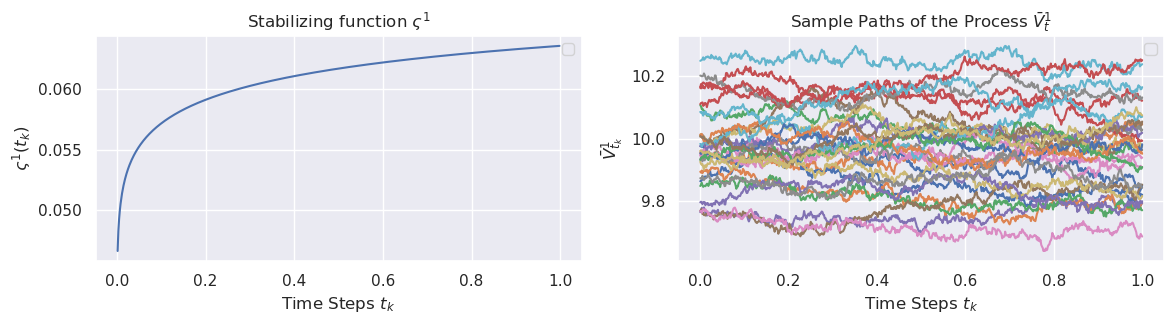

In [65]:
t_values = np.arange(1,simulator.n)*simulator.dt  # Time points to evaluate ζ(t)
# Compute coefficients c_k
zeta_values = simulator.zeta_t(t_values, simulator.c_coeffs)

X, sigma_vals, increments = simulator.simulate_path_cholesky_expanded()

# Create two vertical subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

axes[0].plot(t_values, zeta_values) # , label="Stabilizing function $\varsigma^1$")
axes[0].set_xlabel("Time Steps $t_k$")
axes[0].set_ylabel(r"$\varsigma^1(t_k)$")
axes[0].set_title(r"Stabilizing function $ \varsigma^1$")
axes[0].legend()
# plt.title('Stabilizer function ζ(t)')
        
# Randomly select `n_trajectories` indices
n_trajectories = 30 # 50
indices = np.random.choice(simulator.M, n_trajectories, replace=False)
for m in indices:  # Iterate over the randomly selected indices
    axes[1].plot(simulator.times, X[:, m]) # , label=f"Trajectory {m + 1}")
axes[1].set_xlabel("Time Steps $t_k$")
axes[1].set_ylabel(r"$\bar{V}^1_{t_k}$")
axes[1].set_title(r"Sample Paths of the Process $\bar{V}^1_{t}$")
axes[1].legend()

# fig.suptitle(r'Curves $\text{Var}(X_t)$ and $\mathbb{E}[ \sigma^2(X_t) ]$  as function of time,'+ self.func_latex + f', H={np.round(self.alpha-0.5,2)}, c= {np.round(self.c,3)}, {"{:.1e}".format(self.M)} Samples, scheme = {self.scheme}, '+ r' $X_0$' + f'={self.X0_distribution['type']}', fontsize=16)
# Adjust layout for better spacing between subplots
plt.tight_layout()
# Save the figure
plt.savefig(f'Stabilizer_Samplepaths_H0{int(np.round(100*(simulator.alpha-0.5),2))}_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
# Display the figure
plt.show() 

seed =  6097848684366237223696517596310169373
Processing batch 1/20...
Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:02<00:00, 240.01it/s]


done
Processing batch 2/20...
Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:03<00:00, 196.06it/s]


done
Processing batch 3/20...
Simulating trajectories, scheme 2


...

done
Processing batch 19/20...
Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:01<00:00, 301.49it/s]


done
Processing batch 20/20...
Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:03<00:00, 191.44it/s]


done


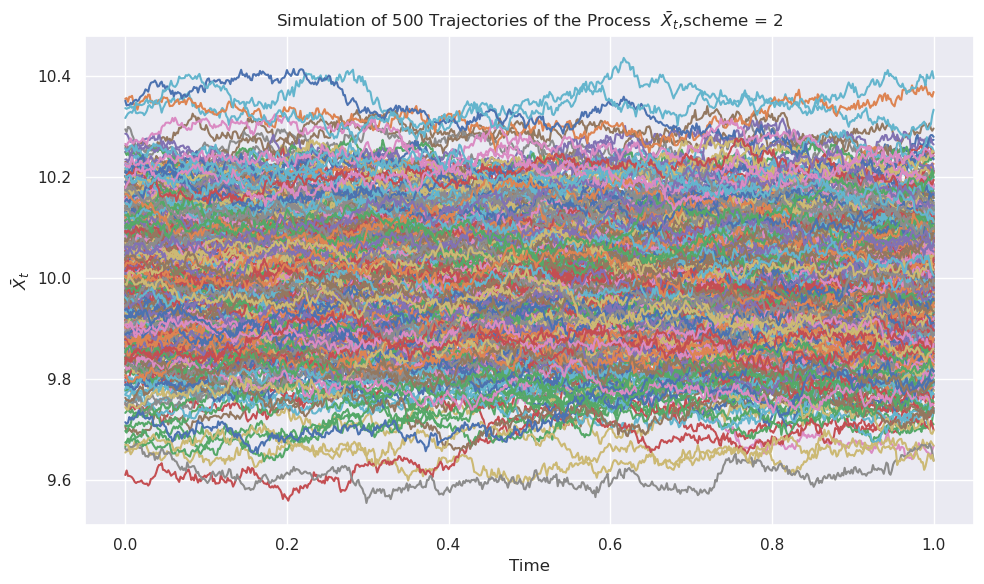

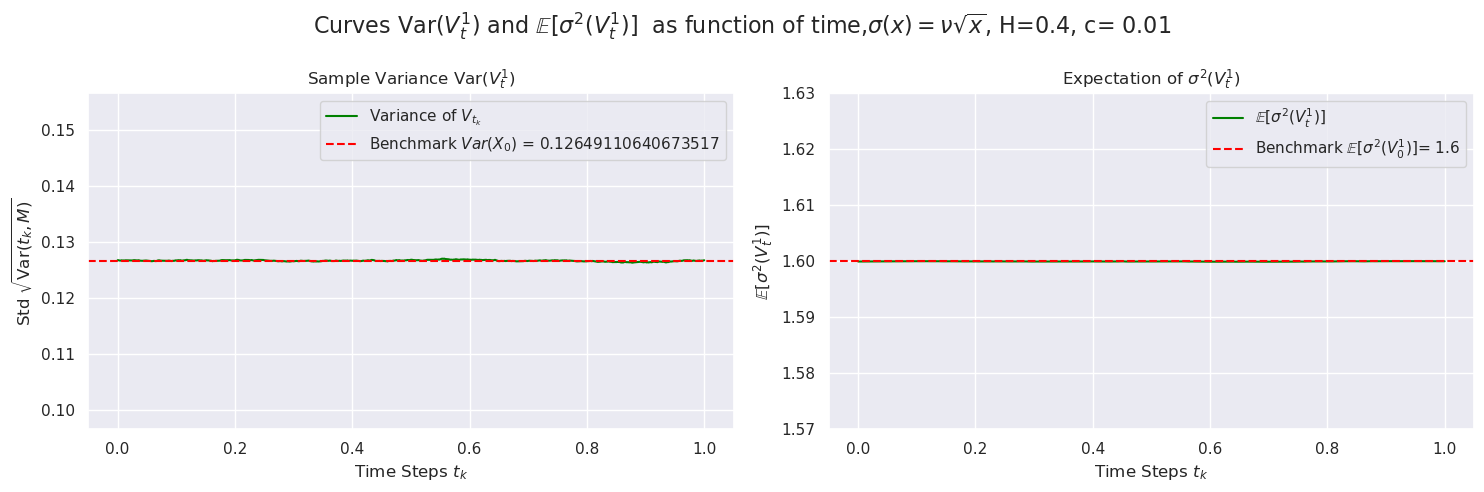

In [13]:
simulator.M = 40000
simulator.scheme = 2
expectation_sigma_square, variances, _, _ = simulator.simulate_batches_compute_moments_plot_trajectories(total_batches=20)
simulator.plot_variance_meansigma_curves(expectation_sigma_square, variances)

In [73]:
def plot_variance_meansigma_curves(simulator, expectation_sigma_square, variances):
    """
    Compute the sample variance for each time step t_k across M realizations of X,
    and the expectation of the square of the second argument.

    Parameters:
    X (ndarray): Array of shape (n, M), where n is the number of time steps and M is the number of realizations.
    sigma_vals (ndarray): Array of shape (n+1, M) for the second argument whose square we want to compute the expectation.

    Returns:
    None (plots the figure with two subplots)
    """
    # Create two vertical subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # First subplot: Plotting the variance of X
    axes[0].plot(simulator.times, variances, label="Variance of $V_{t_k}$", color='green')
    if simulator.experiment_type == 'simulation':
        std_0 = simulator.v0 # np.sqrt(simulator.v0)
        axes[0].axhline(y= std_0, color='red', linestyle='--', label=f"Benchmark $Var(V^1_0)$ = {std_0}") # Benchmark $std(X_0)$ = {std_0}
    else:
        std_0= np.mean(variances[-20:]) # np.mean(np.sqrt(variances)[-20:])
        axes[0].axhline(y= std_0, color='red', linestyle='--', label=f"Target asymtotic $Var(V^1_0)$ = {np.round(std_0,3)}") # Benchmark $std(X_0)$ = {std_0}
        
    axes[0].set_ylim(tuple( [simulator.v0-0.004, simulator.v0+0.004]))
    axes[0].set_xlabel("Time Steps $t_k$")
    axes[0].set_ylabel(r"Std $\sqrt{\text{Var}(t_k, M)}$")
    # axes[0].set_ylabel(r"$\text{Var}(V_{t_k}, M)$") # axes[0].set_ylabel(r"Std $\sqrt{\text{Var}(t_k, M)}$")
    axes[0].set_title(r"Sample Variance $\text{Var}(V^1_t)$")
    axes[0].legend()
    axes[0].grid(True)
    # Second subplot: Plotting the expectation of the square of the second argument
    axes[1].plot(simulator.times, expectation_sigma_square, label=r"$\mathbb{E}[\sigma^2(V^1_t)]$", color='green')
    if simulator.experiment_type == 'simulation':
        axes[1].axhline(y=simulator.expect_sigma_0_2, color='red', linestyle='--', label=r"Benchmark $\mathbb{E}[\sigma^2(V^1_0)]$"+f"= {np.round(simulator.expect_sigma_0_2,3)}")
    else:
        expect_sigma_0_2 = np.mean(expectation_sigma_square[-20:])
        axes[1].axhline(y= expect_sigma_0_2, color='red', linestyle='--', label=r"Target asymtotic $\mathbb{E}[\sigma^2(V^1_t)]$"+f"= {np.round(expect_sigma_0_2,3)}") # 
    axes[1].set_ylim(tuple([simulator.expect_sigma_0_2-0.004, simulator.expect_sigma_0_2+0.004]))
    axes[1].set_xlabel("Time Steps $t_k$")
    axes[1].set_ylabel(r"$\mathbb{E}[ \sigma^2(V^1_t) ]$")
    axes[1].set_title(r"Expectation of $\sigma^2(V^1_t)$")
    axes[1].legend()
    axes[1].grid(True)
    # Add a global title
    fig.suptitle(r'Curves $\text{Var}(V^1_t)$ and $\mathbb{E}[ \sigma^2(V^1_t) ]$  as a function of time, '+ simulator.func_latex + r', $\nu=$'+ f'{nu},  H={np.round(simulator.alpha-0.5,2)}, c= {np.round(simulator.c,3)}', fontsize=16) # {"{:.1e}".format(simulator.M)} Samples, scheme = {self.scheme}, '+ r' $X_0$' + f'={self.X0_distribution['type']}', fontsize=16)
    # Adjust layout for better spacing between subplots
    plt.tight_layout()
    # Save the figure
    plt.savefig(f'curves_variance_meansigma_scheme{simulator.scheme}_H0{int(np.round(100*(simulator.alpha-0.5),2))}_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
    # Display the figure
    plt.show()

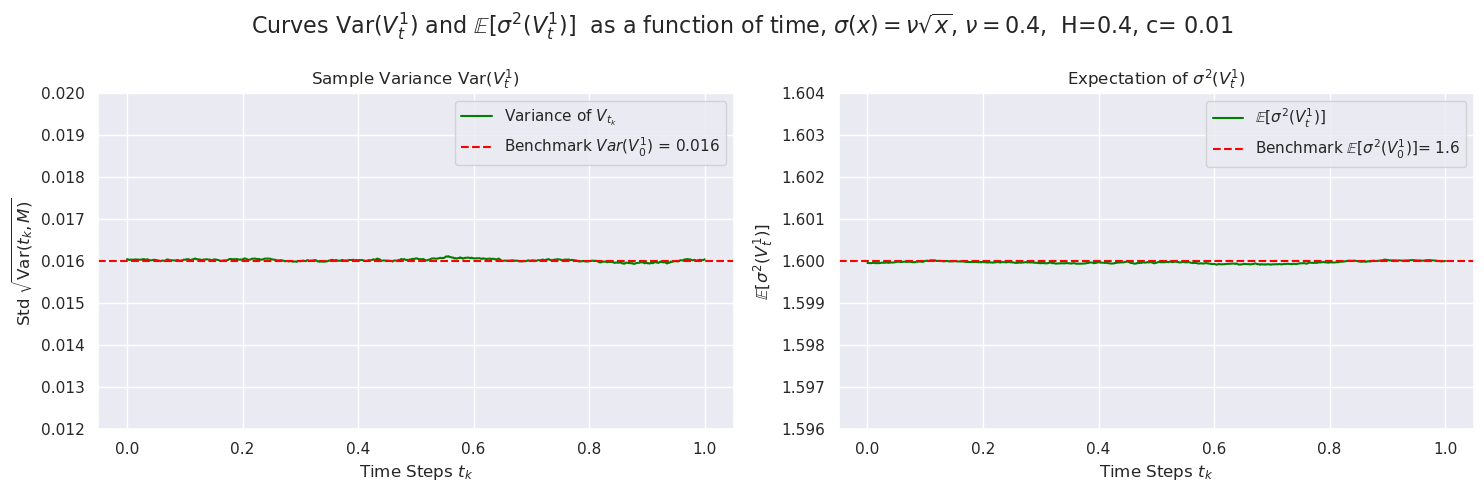

In [75]:
plot_variance_meansigma_curves(simulator, expectation_sigma_square, variances)

## Compute and plot the solution to Fractional Riccati Volterra Integral Equations(FRVIE)

In [ ]:
def fractional_ABM_2D(f, t_grid, alpha):
    """
    Fractional Adams–Bashforth–Moulton scheme in dimension 2.

    Parameters
    ----------
    f : function
        f(t, y) -> (f1, f2)
    T : float
        terminal time
    n : int
        number of time steps
    alpha : array-like
        fractional orders [alpha1, alpha2]

    Returns
    -------
    t_grid : array
        time grid
    y : array (n+1,2)
        solution (psi1, psi2)
    """

    dt = t_grid[1]-t_grid[0]
    n= len(t_grid)-1
    # t = np.linspace(0, T, n+1)

    y = np.zeros((n+1, 2))   # y[:,0] = psi1 , y[:,1] = psi2
    y_pred = np.zeros(2)

    for i in range(2):

        alpha_i = alpha[i]

        for k in range(n):

            # ---------- Predictor ----------
            pred = 0.0

            for j in range(k+1):

                b = (dt**alpha_i / gamma(alpha_i+1)) * (
                    (k+1-j)**alpha_i - (k-j)**alpha_i
                )

                f1, f2 = f(t_grid[j], y[j])
                fij = f1 if i == 0 else f2

                pred += b * fij

            y_pred[i] = pred


            # ---------- Corrector ----------
            corr = 0.0

            for j in range(k+1):

                if j == 0:

                    a_weight = (dt**alpha_i / gamma(alpha_i+2)) * (
                        k**(alpha_i+1) - (k-alpha_i)*(k+1)**alpha_i
                    )

                else:

                    a_weight = (dt**alpha_i / gamma(alpha_i+2)) * (
                        (k-j+2)**(alpha_i+1)
                        + (k-j)**(alpha_i+1)
                        - 2*(k-j+1)**(alpha_i+1)
                    )

                f1, f2 = f(t_grid[j], y[j])
                fij = f1 if i == 0 else f2

                corr += a_weight * fij

            # term j = k+1
            f1p, f2p = f(t_grid[k+1], y_pred)
            f_pred = f1p if i == 0 else f2p

            a_last = dt**alpha_i / gamma(alpha_i+2)

            y[k+1, i] = corr + a_last * f_pred

    return y

In [14]:
def make_f(T, theta, rho, nu, D, varsigma, t_grid, utility="power", gamma_=None):
    """
    Builds f(t,psi) = a + F(T-t,psi)

    varsigma : array (n+1,2)
        σ^i(t_k) values
    """

    theta = np.asarray(theta)
    rho = np.asarray(rho)
    nu = np.asarray(nu)

    # ---- constant term a_i ----
    if utility == "power":

        if gamma_ is None:
            raise ValueError("gamma_ required for power utility")

        a = gamma_ * theta**2 / (2*(1-gamma_))

    elif utility == "exponential":

        a = - theta**2 / 2

    else:
        raise ValueError("utility must be 'power' or 'exponential'")


    def f(t, psi):

        psi = np.asarray(psi)

        # argument of F
        s = T - t

        # index corresponding to s
        k = np.searchsorted(t_grid, s)
        k = min(k, len(t_grid)-1)

        sigma = varsigma[k]   # vector (σ¹, σ²)

        Dpsi = D.T @ psi

        F = np.zeros(2)

        for i in range(2):

            if utility == "power":

                term1 = (gamma_/(1-gamma_))*theta[i]*rho[i]*nu[i]*sigma[i]*psi[i]

                term3 = (nu[i]**2/2) * (
                    (sigma[i]*psi[i])**2
                    + (gamma_/(1-gamma_))*rho[i]**2*(sigma[i]*psi[i])**2
                )

            else:  # exponential

                term1 = - theta[i]*rho[i]*nu[i]*sigma[i]*psi[i]

                term3 = (nu[i]**2/2)*(1-rho[i]**2)*(sigma[i]*psi[i])**2


            F[i] = term1 + Dpsi[i] + term3

        return a + F

    return f

In [16]:
def plot_power_vs_exponential(
    solver,
    T,
    n,
    alpha_list,
    theta,
    rho,
    nu,
    D,
    varsigma,
    t_grid,
    gamma_
):
    """
    Compare Power vs Exponential utility for the same alpha values.
    Left subplot: Power
    Right subplot: Exponential
    """
    fig, axes = plt.subplots(1, 2, figsize=(15,5))
    utilities = ["power", "exponential"]
    for ax, utility in zip(axes, utilities):
        f = make_f(
            T=T,
            theta=theta,
            rho=rho,
            nu=nu,
            D=D,
            varsigma=varsigma,
            t_grid=t_grid,
            utility=utility,
            gamma_=gamma_
        )
        for alpha in alpha_list:
            y = solver(f, t_grid, alpha)
            ax.plot(t_grid, y[:,0], label=r'$\psi^1, \; \alpha_1=$'+f'{alpha[0]}')
            ax.plot(t_grid, y[:,1], label=r'$\psi^2, \; \alpha_2=$'+f'{alpha[1]}')

        ax.set_title(f"{utility.capitalize()} utility")
        ax.set_xlabel("t")
        ax.set_ylabel("ψ(t)")
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    # Save the figure
    plt.savefig(f'FigSolutionPbmax_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
    # Display the figure
    plt.show()

computing tauberian coefficients


100%|████████████████████████████████████████| 24/24 [00:00<00:00, 29995.02it/s]


done: Rayon > T : Yes, [Rayon, T] = [61.68882306685936, 1]
computing tauberian coefficients


100%|████████████████████████████████████████| 24/24 [00:00<00:00, 37857.58it/s]

done: Rayon > T : Yes, [Rayon, T] = [293.54465622478955, 1]


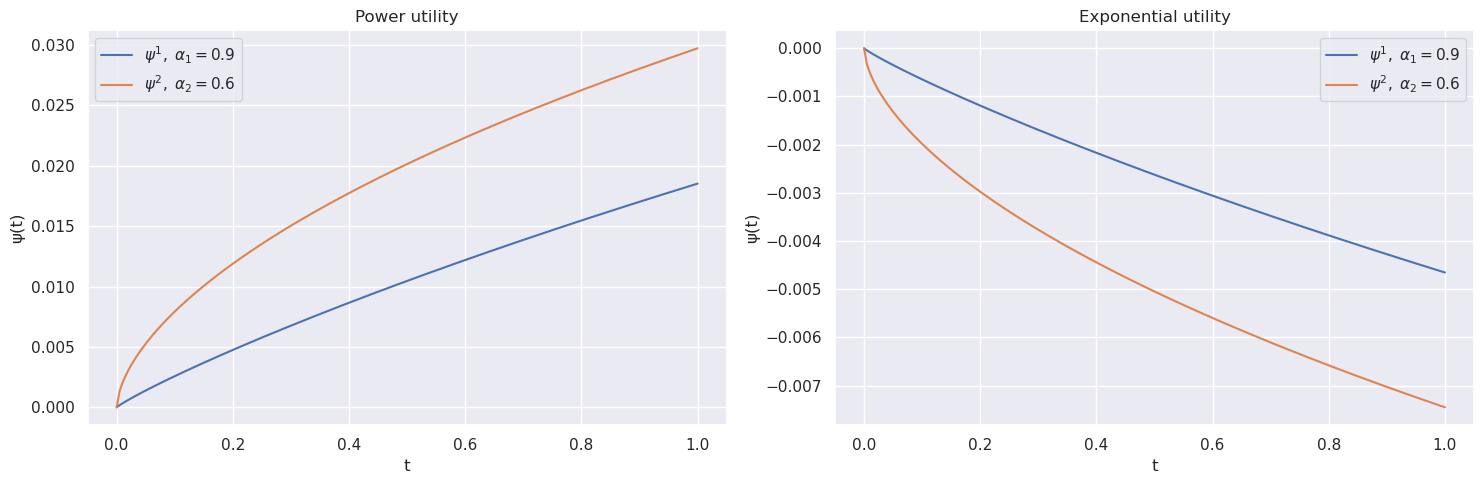

In [298]:
T = 1
N = 200
t_values = np.linspace(0, T, N+1)

gamma_ = 0.8 # 0.5 # 0.2

theta = np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55])
nu = np.array([0.4,0.2])

D = np.array([[-0.2,0],
              [0,-0.1]])
alpha_list = [[0.5 + 0.4, 0.5 + 0.1]]

# \varsigma(t)
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}

varsigma = np.zeros((N+1,2))

config['alpha'] = alpha_list[0][0] # 0.5 + 0.4,
config['lambda_'] = -D[0][0]
config['c'] = 0.01
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)

config['alpha'] = alpha_list[0][1] # 0.5 + 0.1,
config['lambda_'] = -D[1][1]
config['c'] = 0.036
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)

plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho=rho,
    nu=nu,
    D=D,
    varsigma=varsigma,
    t_grid=t_values,
    gamma_=gamma_
)

## Compute and plot Optimal Strategy 

In [18]:
def compute_strategy(psi, t_grid, T, theta, rho, nu, varsigma,
                     utility="power", gamma_=None, r=0.0):
    """
    Compute optimal portfolio π(t) from Riccati solution ψ.

    psi : array (n+1,2)
    varsigma : array (n+1,2)
    """

    n = len(t_grid) - 1
    pi = np.zeros_like(psi)

    for k, t in enumerate(t_grid):

        # index for ψ(T-t)
        s = T - t
        j = np.searchsorted(t_grid, s)
        j = min(j, n)

        for i in range(2):

            base = theta[i] + rho[i]*nu[i]*varsigma[k,i]*psi[j,i]  # rho[i]*nu[i]*varsigma[k,i]*psi[j,i] #

            if utility == "power":

                pi[k,i] = base / (1-gamma_)

            else:  # exponential

                pi[k,i] = (1/gamma_) * np.exp(-r*(T-t)) * base

    return pi

def plot_power_vs_exponential(
    solver,
    T,
    n,
    alpha_list,
    theta,
    rho,
    nu,
    D,
    varsigma,
    t_grid,
    gamma_,
    r=0.0,
    mode="riccati"
):

    fig, axes = plt.subplots(1, 2, figsize=(15,5))
    utilities = ["power", "exponential"]

    for ax, utility in zip(axes, utilities):

        f = make_f(
            T=T,
            theta=theta,
            rho=rho,
            nu=nu,
            D=D,
            varsigma=varsigma,
            t_grid=t_grid,
            utility=utility,
            gamma_=gamma_
        )

        for alpha in alpha_list:

            psi = solver(f, t_grid, alpha)

            if mode == "strategy":
                labels=[r'$\pi^1, \; \alpha_1=$'+f'{alpha[0]}',r'$\pi^2, \; \alpha_2=$'+f'{alpha[1]}']
                y = compute_strategy(
                    psi,
                    t_grid,
                    T,
                    theta,
                    rho,
                    nu,
                    varsigma,
                    utility=utility,
                    gamma_=gamma_,
                    r=r
                )

                ylabel = r'$\pi(t)$'

            else:
                labels=[r'$\psi^1, \; \alpha_1=$'+f'{alpha[0]}',r'$\psi^2, \; \alpha_2=$'+f'{alpha[1]}']
                y = psi
                ylabel = r'$\psi(t)$'

            ax.plot(t_grid, y[:,0], label=labels[0])

            ax.plot(t_grid, y[:,1], label=labels[1])

        ax.set_title(f"{utility.capitalize()} utility")
        ax.set_xlabel("t")
        ax.set_ylabel(ylabel)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    # Save the figure
    plt.savefig(f'FigSolutionPbmax_Mode{mode}_T{int(simulator.T)}_gamma{gamma_}.pdf')  # Sauvegarder sous le nom souhaité
    # Display the figure
    plt.show()

In [18]:
T = 1
N = 400
t_values = np.linspace(0, T, N+1)

gamma_ = 0.5 # 0.5 # 0.2

theta = np.array([0.1,0.1]) # np.array([4.7,3.4]) # np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55])
nu = np.array([0.4,0.2])

D = np.array([[-0.2,0],
              [0,-0.1]])
alpha_list = [[0.5 + 0.4, 0.5 + 0.1]]

# \varsigma(t)
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}

varsigma = np.zeros((N+1,2))

config['alpha'] = alpha_list[0][0] # 0.5 + 0.4,
config['lambda_'] = -D[0][0]
config['c'] = 0.01
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)

config['alpha'] = alpha_list[0][1] # 0.5 + 0.1,
config['lambda_'] = -D[1][1]
config['c'] = 0.036
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)

computing tauberian coefficients


100%|████████████████████████████████████████| 24/24 [00:00<00:00, 14847.09it/s]


done: Rayon > T : Yes, [Rayon, T] = [61.68882306685936, 1]
computing tauberian coefficients


100%|████████████████████████████████████████| 24/24 [00:00<00:00, 16494.07it/s]

done: Rayon > T : Yes, [Rayon, T] = [293.54465622478955, 1]


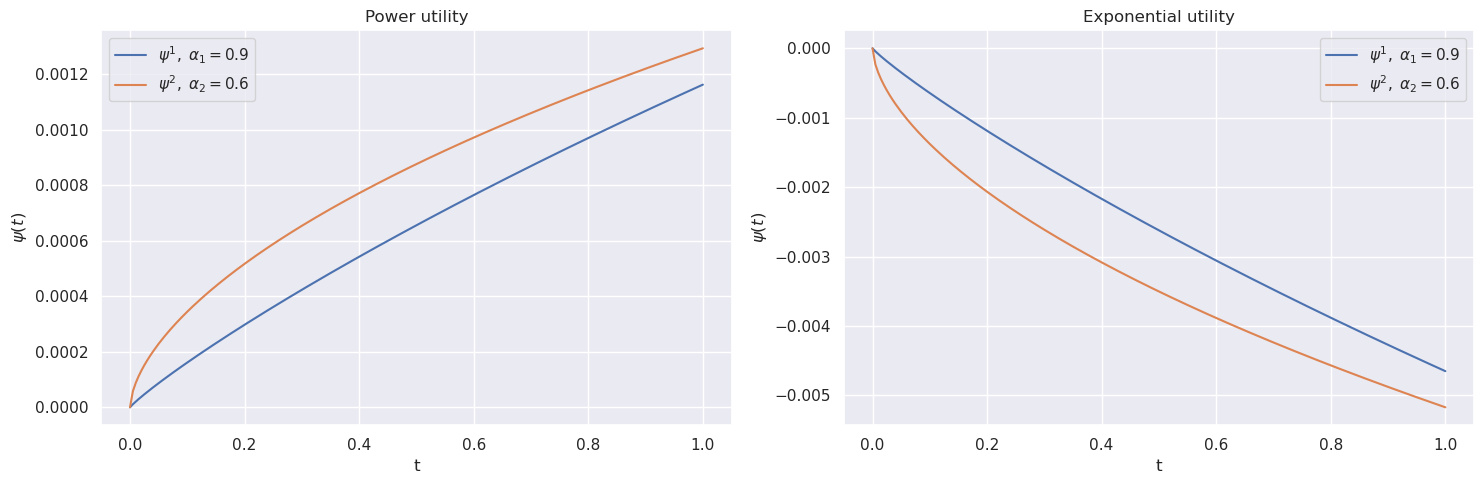

In [378]:
plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho=rho,
    nu=nu,
    D=D,
    varsigma=varsigma,
    t_grid=t_values,
    gamma_=gamma_,
    mode="riccati"
)

computing tauberian coefficients


100%|█████████████████████████████████████████| 74/74 [00:00<00:00, 6596.50it/s]


done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 1]
computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 10956.98it/s]

done: Rayon > T : Yes, [Rayon, T] = [39.946675595999636, 1]


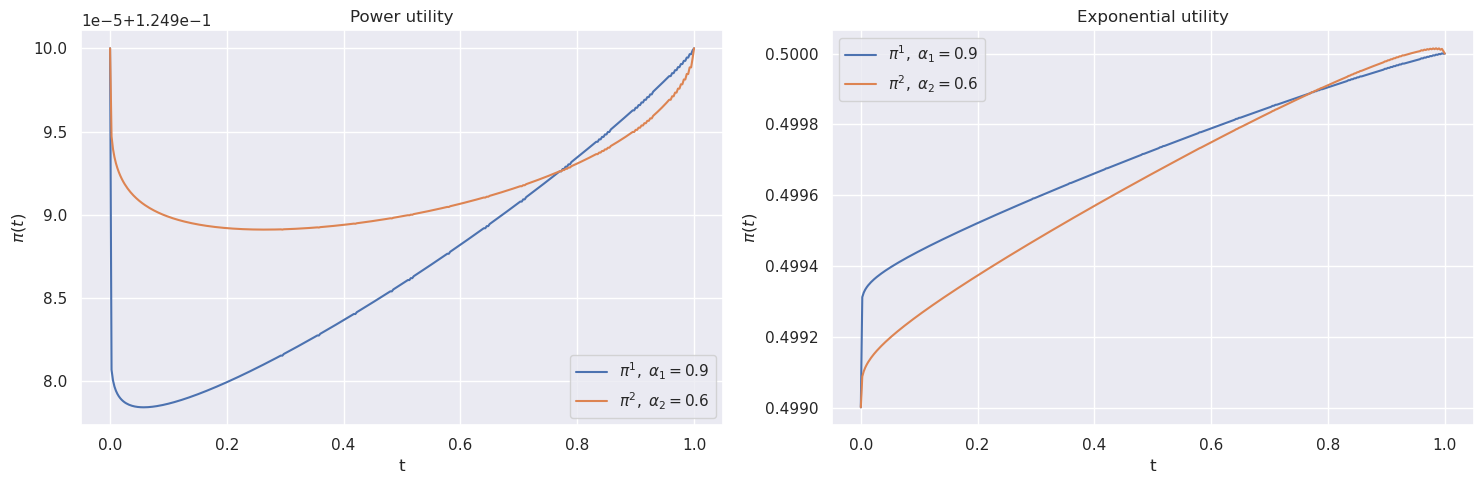

In [22]:
T = 1
config['nmax'] = 75
N = 400
t_values = np.linspace(0, T, N+1)

gamma_ = 0.2 # 0.5 # 0.2

theta = np.array([0.1,0.1]) # np.array([4.7,3.4]) # np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55])
nu = np.array([0.4,0.2])

D = np.array([[-0.2,0],
              [0,-0.6]])
alpha_list = [[0.5 + 0.4, 0.5 + 0.1]]

# \varsigma(t)
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}

varsigma = np.zeros((N+1,2))

config['alpha'] = alpha_list[0][0] # 0.5 + 0.4,
config['lambda_'] = -D[0][0]
config['c'] = 0.01
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)

config['alpha'] = alpha_list[0][1] # 0.5 + 0.1,
config['lambda_'] = -D[1][1]
config['c'] = 0.03
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)

plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho = rho,
    nu = nu,
    D = D,
    varsigma = varsigma,
    t_grid = t_values,
    gamma_=gamma_,
    r=0.002,
    mode="strategy"
)

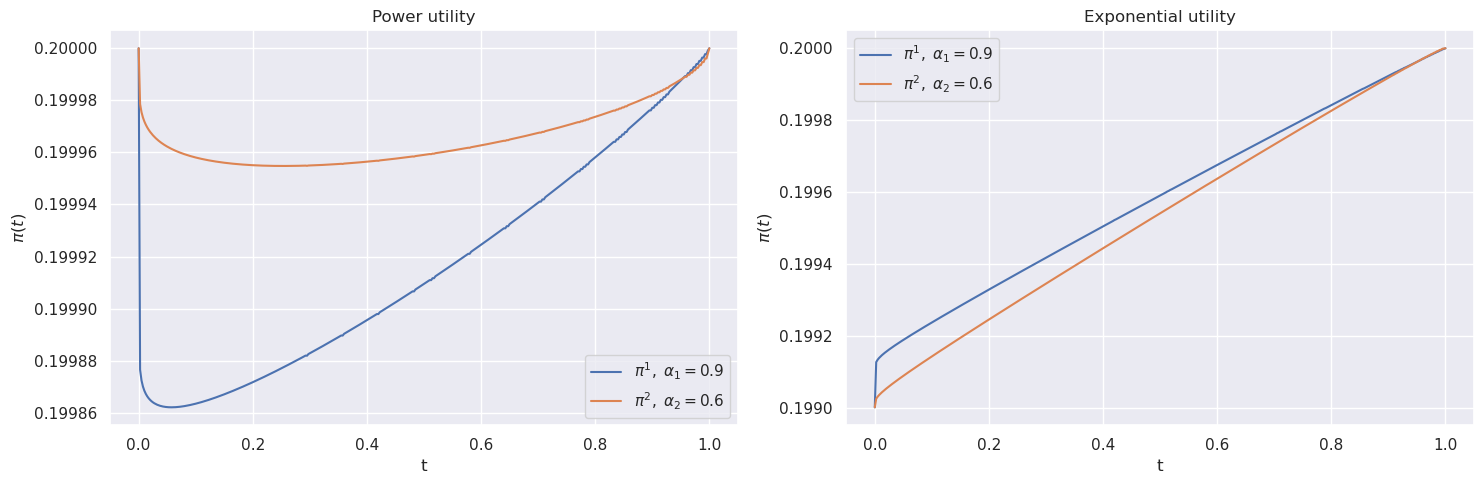

In [408]:
plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho = rho,
    nu = nu,
    D = D,
    varsigma = varsigma,
    t_grid = t_values,
    gamma_=gamma_,
    r=0.005,
    mode="strategy"
)

computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 34752.94it/s]


done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 5]
computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 35290.33it/s]

done: Rayon > T : Yes, [Rayon, T] = [39.946675595999636, 5]


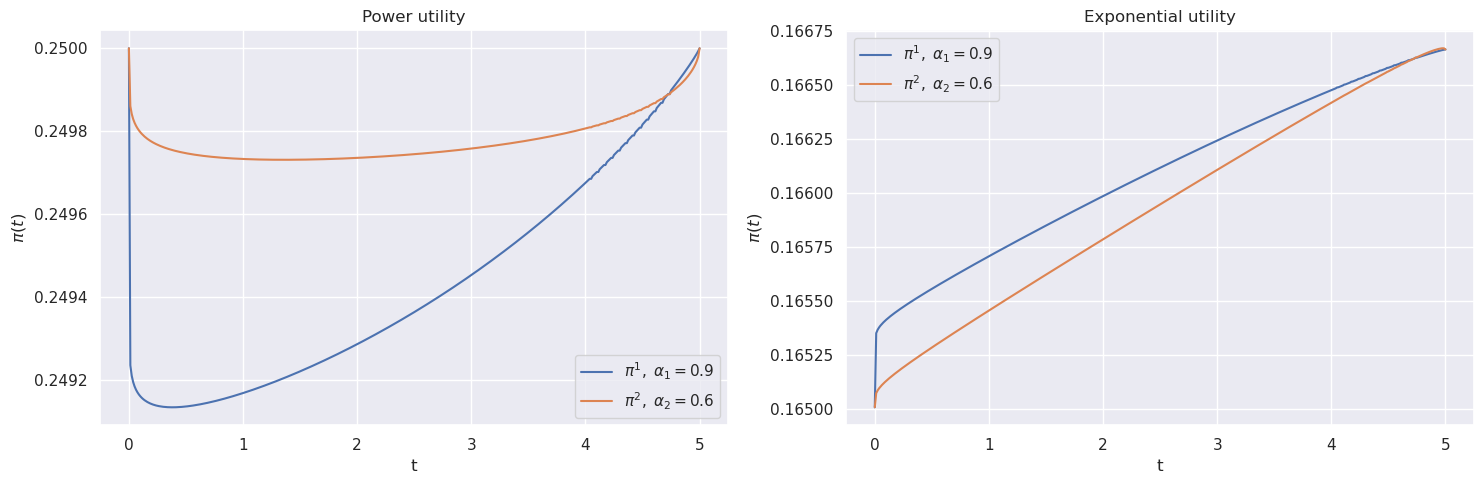

In [34]:
T = 5
config['nmax'] = 75
N = 400
t_values = np.linspace(0, T, N+1)

gamma_ = 0.6 # 0.2

theta = np.array([0.1,0.1]) # np.array([4.7,3.4]) # np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55])
nu = np.array([0.4,0.2])

D = np.array([[-0.2,0],
              [0,-0.6]])
alpha_list = [[0.5 + 0.4, 0.5 + 0.1]]

# \varsigma(t)
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}

varsigma = np.zeros((N+1,2))

config['alpha'] = alpha_list[0][0] # 0.5 + 0.4,
config['lambda_'] = -D[0][0]
config['c'] = 0.01
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)

config['alpha'] = alpha_list[0][1] # 0.5 + 0.1,
config['lambda_'] = -D[1][1]
config['c'] = 0.03
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)

plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho = rho,
    nu = nu,
    D = D,
    varsigma = varsigma,
    t_grid = t_values,
    gamma_=gamma_,
    r=0.002,
    mode="strategy"
)

computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 34944.66it/s]


done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 5]
computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 35411.12it/s]

done: Rayon > T : Yes, [Rayon, T] = [39.946675595999636, 5]


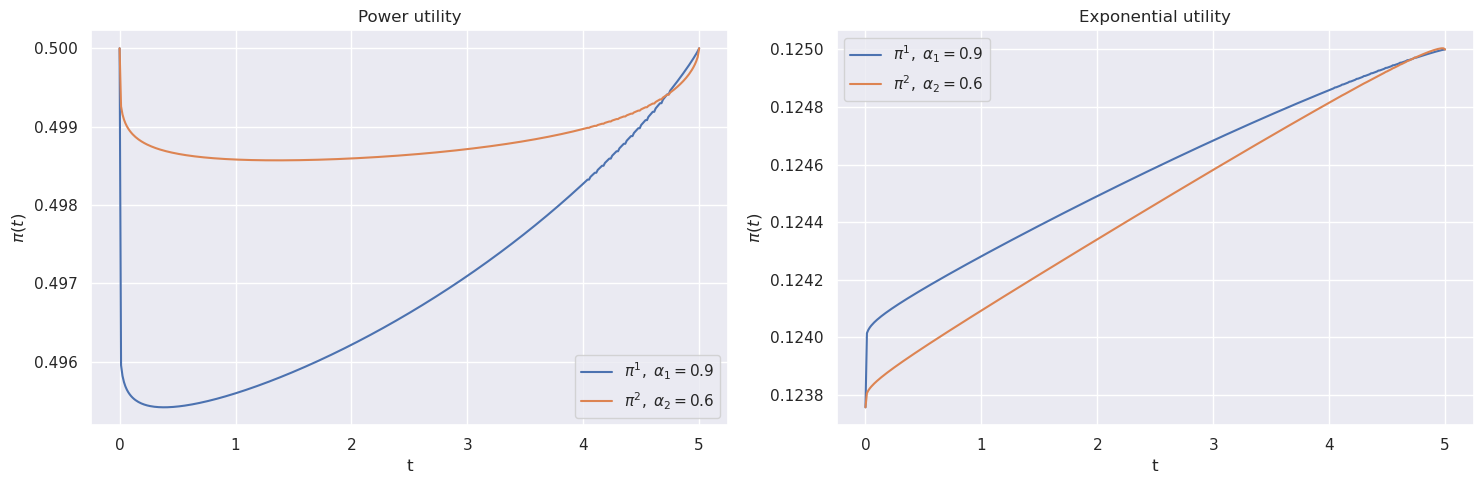

In [38]:
T = 5
config['nmax'] = 75
N = 400
t_values = np.linspace(0, T, N+1)

gamma_ = 0.8

theta = np.array([0.1,0.1]) # np.array([4.7,3.4]) # np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55])
nu = np.array([0.4,0.2])

D = np.array([[-0.2,0],
              [0,-0.6]])
alpha_list = [[0.5 + 0.4, 0.5 + 0.1]]

# \varsigma(t)
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}

varsigma = np.zeros((N+1,2))

config['alpha'] = alpha_list[0][0] # 0.5 + 0.4,
config['lambda_'] = -D[0][0]
config['c'] = 0.01
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)

config['alpha'] = alpha_list[0][1] # 0.5 + 0.1,
config['lambda_'] = -D[1][1]
config['c'] = 0.03
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)

plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho = rho,
    nu = nu,
    D = D,
    varsigma = varsigma,
    t_grid = t_values,
    gamma_=gamma_,
    r=0.002,
    mode="strategy"
)

computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 29582.40it/s]


done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 1]
computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 34498.00it/s]

done: Rayon > T : Yes, [Rayon, T] = [39.946675595999636, 1]


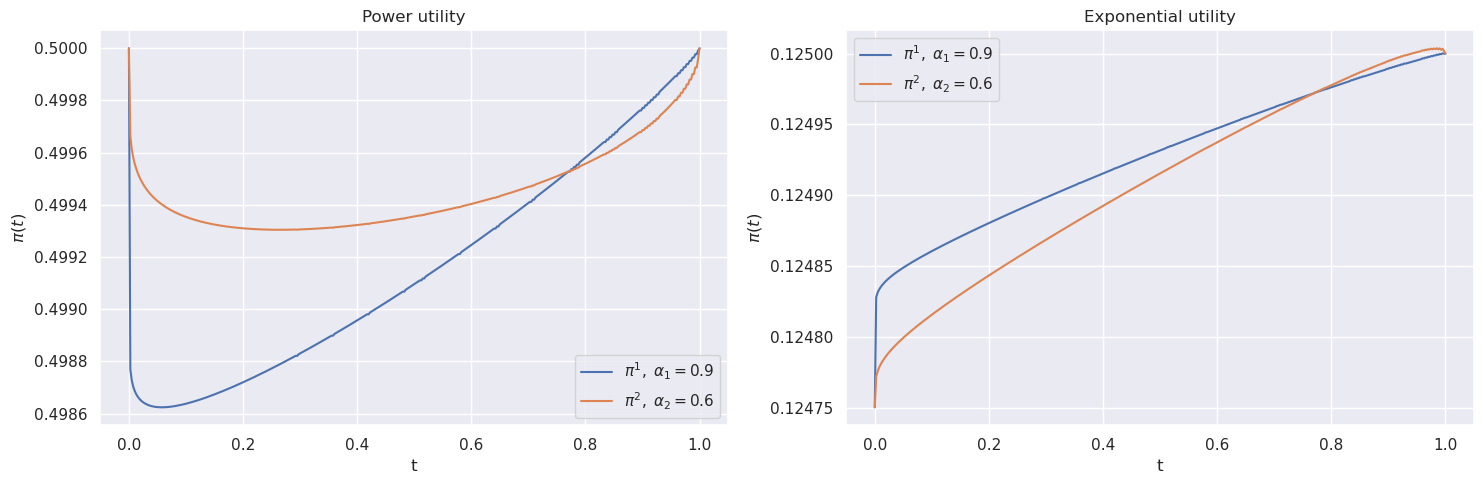

In [40]:
T = 1
config['nmax'] = 75
N = 400
t_values = np.linspace(0, T, N+1)

gamma_ = 0.8

theta = np.array([0.1,0.1]) # np.array([4.7,3.4]) # np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55])
nu = np.array([0.4,0.2])

D = np.array([[-0.2,0],
              [0,-0.6]])
alpha_list = [[0.5 + 0.4, 0.5 + 0.1]]

# \varsigma(t)
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}

varsigma = np.zeros((N+1,2))

config['alpha'] = alpha_list[0][0] # 0.5 + 0.4,
config['lambda_'] = -D[0][0]
config['c'] = 0.01
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)

config['alpha'] = alpha_list[0][1] # 0.5 + 0.1,
config['lambda_'] = -D[1][1]
config['c'] = 0.03
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)

plot_power_vs_exponential(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha_list=alpha_list,
    theta=theta,
    rho = rho,
    nu = nu,
    D = D,
    varsigma = varsigma,
    t_grid = t_values,
    gamma_=gamma_,
    r=0.002,
    mode="strategy"
)

## References

[1] Emmanuel Gnabeyeu. (2026) *On the mean-variance problem through the lens of
multivariate fake stationary affine Volterra dynamics.*

[2] Emmanuel Gnabeyeu, Gilles Pagès and Mathieu Rosenbaum. (2025) *On Inhomogeneous Affine Volterra Processes: Stationarity
and Applications to the Volterra Heston Model.*

[3] Emmanuel Gnabeyeu and Gilles Pagès. (2025) *On a Stationarity Theory for Stochastic Volterra Integral
Equations.*